In [1]:
# Principal Component Analysis (PCA)

### Set Up

In [2]:
# install required packages
import requests
import pandas as pd
import json
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn import decomposition #PCA

from itertools import cycle, islice

from pandas.plotting import parallel_coordinates

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


### National Park Service Data

#### National Park Service Sites

In [1]:
# National Park Service API Set Up
nps_url_base = "developer.nps.gov/api/v1"

my_api_key = 'your_api_key_here'

nps_url_request = "https://developer.nps.gov/api/v1/parks?limit=500&get=designation,fullName,id,name,parkCode,states&for=parkCode:*&api_key=" + my_api_key

# need to update limit to 500 for full run

In [4]:
# Execute API request
response = requests.get(nps_url_request)

In [5]:
# Check status of API request, report status, and if good transform data into dataframe and print column names
if response.status_code == 200:
    print('Successful API download')
    nps_api_exp = json.loads(response.text)
    nps_data = pd.DataFrame(nps_api_exp['data'])
    print(nps_data.columns)
else: print(f'API download failed. Error code: {response.status_code}')

Successful API download
Index(['id', 'url', 'fullName', 'parkCode', 'description', 'latitude',
       'longitude', 'latLong', 'activities', 'topics', 'states', 'contacts',
       'entranceFees', 'entrancePasses', 'fees', 'directionsInfo',
       'directionsUrl', 'operatingHours', 'addresses', 'images', 'weatherInfo',
       'name', 'designation', 'multimedia', 'relevanceScore'],
      dtype='str')


In [6]:
# Select parameters of interest from API data set
nps_sites0 = nps_data[['fullName','name','parkCode','designation','states']]

# Rename columns
nps_sites0 = nps_sites0.rename(columns={'fullName': 'Site_Full_Name', 'name': 'Site_Name', 'parkCode': 'Park_Code', 'designation': 'Designation', 'states': 'State List'})

# Capitalize park code for consistent formatting
nps_sites0['Park_Code'] = nps_sites0['Park_Code'].str.upper()

#nps_sites.head()

In [7]:
nps_sites_nodesig = nps_sites0[nps_sites0['Designation']==""]
nps_sites_nodesig

nps_sites_nodesig['Designation'] = 'Undesignated'

#nps_sites_nodesig

In [8]:
nps_sites_desig = nps_sites0[nps_sites0['Designation']!=""]
nps_sites_desig

,Site_Full_Name,Site_Name,Park_Code,Designation,State List
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA
4,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY
5,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE
...,...,...,...,...,...
469,Yorktown Battlefield Part of Colonial National...,Yorktown Battlefield,YORK,Part of Colonial National Historical Park,VA
470,Yosemite National Park,Yosemite,YOSE,National Park,CA
471,Yucca House National Monument,Yucca House,YUHO,National Monument,CO
472,Yukon - Charley Rivers National Preserve,Yukon - Charley Rivers,YUCH,National Preserve,AK


In [9]:
nps_sites = pd.concat([nps_sites_desig, nps_sites_nodesig], ignore_index = True)
nps_sites.sort_values(by = 'Park_Code')
nps_sites.head()

,Site_Full_Name,Site_Name,Park_Code,Designation,State List
0,Abraham Lincoln Birthplace National Historical...,Abraham Lincoln Birthplace,ABLI,National Historical Park,KY
1,Acadia National Park,Acadia,ACAD,National Park,ME
2,Adams National Historical Park,Adams,ADAM,National Historical Park,MA
3,African Burial Ground National Monument,African Burial Ground,AFBG,National Monument,NY
4,Agate Fossil Beds National Monument,Agate Fossil Beds,AGFO,National Monument,NE


In [10]:
# Break out list of sites by individual states
# (will include duplicate listings for parks spanning multiple states)
nps_sites_state = nps_sites[['Park_Code','State List','Designation']]

#nps_sites_state['State Abb'] = nps_sites['State List']

nps_sites_state['State Abb'] = (nps_sites_state['State List'].str.split(','))

nps_sites_state = nps_sites_state.explode('State Abb')

nps_sites_state = nps_sites_state.reset_index(drop=True)

#### Visitor Data

In [11]:
# Visitation Data

visit_file_1 = "Data/Annual Visitation By Park (1979-1985).csv"

visit_1_load = pd.read_csv(visit_file_1)

#visit_1_load.head(10)

visit_1_load.columns = visit_1_load.iloc[5]

visit_1_load = visit_1_load.iloc[6:].reset_index(drop = True)

visit_1 = visit_1_load.drop(visit_1_load.columns[[0,9,10,11]], axis=1)

#visit_1.head(10)

# Convert from pivot table to flat table format

visit_1_fl = visit_1.set_index('Park Name').stack().reset_index()

visit_1_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_1_fl.head(10)

visit_file_2 = "Data/Annual Visitation By Park (1986-2006).csv"

visit_2_load = pd.read_csv(visit_file_2)

#visit_2_load.head(10)

visit_2_load.columns = visit_2_load.iloc[5]

visit_2_load = visit_2_load.iloc[6:].reset_index(drop = True)

#visit_2_load.head(10)

visit_2 = visit_2_load.drop(visit_2_load.columns[[0,11,12,24]], axis=1)

#visit_2.head(10)

# Convert from pivot table to flat table format

visit_2_fl = visit_2.set_index('Park Name').stack().reset_index()

visit_2_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_2_fl.head()

visit_file_3 = "Data/Annual Visitation By Park (2006-2025).csv"

visit_3_load = pd.read_csv(visit_file_3)

#visit_3_load.head(10)

visit_3_load.columns = visit_3_load.iloc[5]

visit_3_load = visit_3_load.iloc[6:].reset_index(drop = True)

#visit_3_load.head(10)

visit_3 = visit_3_load.drop(visit_3_load.columns[[0,11,12,24]], axis=1)

#visit_3.head(10)

# Convert from pivot table to flat table format

visit_3_fl = visit_3.set_index('Park Name').stack().reset_index()

visit_3_fl.rename(columns={5: "Year", 0: "Visitors"}, inplace=True)

#visit_3_fl.head()

In [12]:
# Concatenate Visitor Totals from Tables

visitors = pd.concat([visit_1_fl, visit_2_fl, visit_3_fl], ignore_index=True)

visitors = visitors.sort_values(by=['Park Name','Year'])

visitors.head()

#print(visitors.shape)

,Park Name,Year,Visitors
0,Abraham Lincoln Birthplace NHP,1979,"271,231"
1,Abraham Lincoln Birthplace NHP,1980,"239,074"
2,Abraham Lincoln Birthplace NHP,1981,"252,245"
3,Abraham Lincoln Birthplace NHP,1982,"318,707"
4,Abraham Lincoln Birthplace NHP,1983,"256,126"


In [13]:
# Remove any rows without park name
visitors.dropna(subset = ['Park Name'], inplace = True)

#print(visitors.shape)

# Convert numbers strings to numbers
visitors['Visitors'] = visitors['Visitors'].str.replace(",","")

visitors['Visitors'] = pd.to_numeric(visitors['Visitors'])
visitors['Year'] = pd.to_numeric(visitors['Year'])

# Replace NA values with 0
visitors['Visitors'] = visitors['Visitors'].fillna(0)
#visitors['Visitors Scaled'] = visitors['Visitors Scaled'].fillna(0)

#visitors['Visitors'].dtype


In [14]:
# Import list of Site Abbreviations

visit_abb_file = "Data/Visitor_Sites_Codes.csv"

visitor_park_abb_load = pd.read_csv(visit_abb_file)

#visitor_park_abb_load.head()

visitor_park_abb = visitor_park_abb_load[['Park Name','Park_Code']]

#visitor_park_abb.head()

# Join site abbreviations to data frame

visitors = pd.merge(visitors, visitor_park_abb, on='Park Name', how='left')

visitors['Code_Year'] = visitors['Park_Code'] + '-' + visitors['Year'].astype(str)

visitors.head()

,Park Name,Year,Visitors,Park_Code,Code_Year
0,Abraham Lincoln Birthplace NHP,1979,271231.0,ABLI,ABLI-1979
1,Abraham Lincoln Birthplace NHP,1980,239074.0,ABLI,ABLI-1980
2,Abraham Lincoln Birthplace NHP,1981,252245.0,ABLI,ABLI-1981
3,Abraham Lincoln Birthplace NHP,1982,318707.0,ABLI,ABLI-1982
4,Abraham Lincoln Birthplace NHP,1983,256126.0,ABLI,ABLI-1983


In [15]:
# Add designation to data frame for additional filtering
# designation list
nps_sites_desiglist = nps_sites[['Park_Code','Designation']]

visitor_park_wdesig = pd.merge(visitor_park_abb,nps_sites_desiglist,on = 'Park_Code', how = 'left')

visitor_park_wdesig.drop(columns=['Park Name'], inplace=True)

visitor_park_wdesig.head()

,Park_Code,Designation
0,ABLI,National Historical Park
1,ACAD,National Park
2,ADAM,National Historical Park
3,AFBG,National Monument
4,AGFO,National Monument


In [16]:
# Total visitors by year
visitors_avg = visitors.groupby('Park_Code')['Visitors'].mean().reset_index()

#vis_avg_max = visitors_avg['Visitors'].max()

#visitors_avg['Visitors Scaled'] = visitors_avg['Visitors']/vis_avg_max

visitors_avg.head(10)

,Park_Code,Visitors
0,ABLI,2.445329e+05
1,ACAD,3.024557e+06
2,ADAM,1.059699e+05
3,AFBG,4.230210e+04
4,AGFO,1.456764e+04
5,ALAG,6.650000e+01
6,ALFL,3.956468e+03
7,ALPO,1.323603e+05
8,AMCH,6.442000e+02
9,AMIS,1.275000e+06


In [17]:
visitors_avg_0 = pd.merge(visitors_avg, visitor_park_wdesig,on = 'Park_Code', how = 'left')
visitors_avg_0.head()

,Park_Code,Visitors,Designation
0,ABLI,2.445329e+05,National Historical Park
1,ACAD,3.024557e+06,National Park
2,ADAM,1.059699e+05,National Historical Park
3,AFBG,4.230210e+04,National Monument
4,AGFO,1.456764e+04,National Monument


#### National Park Site Area Data

In [18]:
# Load Nat'l Park Acreage Data

nps_area_file = "Data/NPS-Acreage-12-31-2025.csv"

nps_area_load = pd.read_csv(nps_area_file)

nps_area_load.head()

# Set first row to be header
nps_area_load.columns = nps_area_load.iloc[0]

nps_area_load = nps_area_load[1:].reset_index(drop = True)

nps_area_load['Gross Area Acres'] = pd.to_numeric(nps_area_load['Gross Area Acres'].str.replace(",",""))

# Remove notes from bottom of table
nps_area_load = nps_area_load.dropna(subset=['Region'])

# Downselect fields
nps_area = nps_area_load[['Area Name','Region','State','Gross Area Acres']]

# Scale area by max area value
#GAAmax = max(nps_area['Gross Area Acres'])

#nps_area['Gross Area Scaled'] = nps_area['Gross Area Acres']/GAAmax

nps_area.head(20)

,Area Name,Region,State,Gross Area Acres
0,A LINCOLN BIRTHPL NHP,1,KY,344.50
1,ACADIA NP,1,ME,49076.65
2,ADAMS NHP,1,MA,23.82
3,AFRICAN BURIAL GROUND NM,1,NY,0.35
4,AGATE FOSSIL BEDS NM,5,NE,3057.87
5,ALAGNAK WILD RVR,11,AK,30664.79
6,ALIBATES FLINT QUARRIES N,6,TX,1370.97
7,ALLEGHENY PRTGE RR NHS,1,PA,1284.27
8,AMACHE NHS,7,CO,472.59
9,AMISTAD NRA,6,TX,62945.15


In [19]:
area_file_code = "Data/nps_area_list_codes.csv"

area_codes_load = pd.read_csv(area_file_code)
area_codes_load.head()

area_codes = area_codes_load[['Area Name','Park_Code']]

In [20]:
nps_area = pd.merge(nps_area,area_codes,on = 'Area Name', how = 'left')

nps_area.head()


,Area Name,Region,State,Gross Area Acres,Park_Code
0,A LINCOLN BIRTHPL NHP,1,KY,344.50,ABLI
1,ACADIA NP,1,ME,49076.65,ACAD
2,ADAMS NHP,1,MA,23.82,ADAM
3,AFRICAN BURIAL GROUND NM,1,NY,0.35,AFBG
4,AGATE FOSSIL BEDS NM,5,NE,3057.87,AGFO


In [21]:
nps_area_red = nps_area[['Park_Code','Gross Area Acres']]

nps_area_red

,Park_Code,Gross Area Acres
0,ABLI,344.50
1,ACAD,49076.65
2,ADAM,23.82
3,AFBG,0.35
4,AGFO,3057.87
...,...,...
432,YELL,2219790.71
433,YOSE,761747.50
434,YUHO,195.07
435,YUCH,2526512.44


In [22]:
nps_sites_1 = nps_sites[['Park_Code','State List']]

nps_sites_1['State Count'] = nps_sites_1['State List'].str.count(',')+1

nps_sites_1.head()


,Park_Code,State List,State Count
0,ABLI,KY,1
1,ACAD,ME,1
2,ADAM,MA,1
3,AFBG,NY,1
4,AGFO,NE,1


### Climate Data

In [23]:
# List of CE Regions and assigned states

cei_regions_file = "Data/CEI_Regions_States.csv"

cei_reg_load = pd.read_csv(cei_regions_file)

cei_reg_load.head(10)

,CEI Region,State,State Abb
0,Northwest,Washington,WA
1,Northwest,Oregon,OR
2,Northwest,Idaho,ID
3,West,California,CA
4,West,Nevada,NV
5,Southwest,Utah,UT
6,Southwest,Colorado,CO
7,Southwest,Arizona,AZ
8,Southwest,New Mexico,NM
9,Northern Rockies and Plains,Montana,MT


In [24]:
cei_file_us = "Data/CEI_ContigUS.csv"

cei_us_load = pd.read_csv(cei_file_us)

cei_us_load.columns = cei_us_load.iloc[0]

cei_us_load = cei_us_load.iloc[1:].reset_index(drop = False)

cei_us_load = cei_us_load.rename(columns={'Date': '','index': 'Year'})

cei_us_load['Year'] = pd.to_numeric(cei_us_load['Year'])

cei_us_load['Percentage Area'] = pd.to_numeric(cei_us_load['Percentage Area'])/100

cei_us = cei_us_load

cei_us.head(10)

Date,Year,Percentage Area
0,1910,0.2292
1,1911,0.2416
2,1912,0.3592
3,1913,0.1926
4,1914,0.1990
5,1915,0.2138
6,1916,0.2898
7,1917,0.3394
8,1918,0.1168
9,1919,0.2014


In [25]:
# Set up US value to be used for the "Multiple" region

cei_mult = cei_us
cei_mult['Region'] = 'Multiple'
cei_mult

Date,Year,Percentage Area,Region
0,1910,0.2292,Multiple
1,1911,0.2416,Multiple
2,1912,0.3592,Multiple
3,1913,0.1926,Multiple
4,1914,0.1990,Multiple
...,...,...,...
111,2021,0.3814,Multiple
112,2022,0.1758,Multiple
113,2023,0.3080,Multiple
114,2024,0.4590,Multiple


In [26]:
cei_file_1 = "Data/CEI_Northwest.csv"

reg_name = "Northwest"

cei_1_load = pd.read_csv(cei_file_1)

cei_1_load.columns = cei_1_load.iloc[0]

cei_1_load = cei_1_load.iloc[1:].reset_index(drop = False)

cei_1_load = cei_1_load.rename(columns={'Date': '','index': 'Year'})

cei_1_load['Region'] = reg_name

#cei_1_load.head(10)

cei_file_2 = "Data/CEI_Southwest.csv"

reg_name = "Southwest"

cei_2_load = pd.read_csv(cei_file_2)

cei_2_load.columns = cei_2_load.iloc[0]

cei_2_load = cei_2_load.iloc[1:].reset_index(drop = False)

cei_2_load = cei_2_load.rename(columns={'Date': '','index': 'Year'})

cei_2_load['Region'] = reg_name

#cei_2_load.head(10)

cei_file_3 = "Data/CEI_South.csv"

reg_name = "South"

cei_3_load = pd.read_csv(cei_file_3)

cei_3_load.columns = cei_3_load.iloc[0]

cei_3_load = cei_3_load.iloc[1:].reset_index(drop = False)

cei_3_load = cei_3_load.rename(columns={'Date': '','index': 'Year'})

cei_3_load['Region'] = reg_name

#cei_3_load.head(10)

cei_file_4 = "Data/CEI_Northeast.csv"

reg_name = "Northeast"

cei_4_load = pd.read_csv(cei_file_4)

cei_4_load.columns = cei_4_load.iloc[0]

cei_4_load = cei_4_load.iloc[1:].reset_index(drop = False)

cei_4_load = cei_4_load.rename(columns={'Date': '','index': 'Year'})

cei_4_load['Region'] = reg_name

#cei_4_load.head(10)

cei_file_5 = "Data/CEI_NorthernRockiesandPlains.csv"

reg_name = "Northern Rockies and Plains"

cei_5_load = pd.read_csv(cei_file_5)

cei_5_load.columns = cei_5_load.iloc[0]

cei_5_load = cei_5_load.iloc[1:].reset_index(drop = False)

cei_5_load = cei_5_load.rename(columns={'Date': '','index': 'Year'})

cei_5_load['Region'] = reg_name

#cei_5_load.head(10)

cei_file_6 = "Data/CEI_OhioValley.csv"

reg_name = "Ohio Valley"

cei_6_load = pd.read_csv(cei_file_6)

cei_6_load.columns = cei_6_load.iloc[0]

cei_6_load = cei_6_load.iloc[1:].reset_index(drop = False)

cei_6_load = cei_6_load.rename(columns={'Date': '','index': 'Year'})

cei_6_load['Region'] = reg_name

#cei_6_load.head(10)

cei_file_7 = "Data/CEI_UpperMidwest.csv"

reg_name = "Upper Midwest"

cei_7_load = pd.read_csv(cei_file_7)

cei_7_load.columns = cei_7_load.iloc[0]

cei_7_load = cei_7_load.iloc[1:].reset_index(drop = False)

cei_7_load = cei_7_load.rename(columns={'Date': '','index': 'Year'})

cei_7_load['Region'] = reg_name

#cei_7_load.head(10)

cei_file_8 = "Data/CEI_Southeast.csv"

reg_name = "Southeast"

cei_8_load = pd.read_csv(cei_file_8)

cei_8_load.columns = cei_8_load.iloc[0]

cei_8_load = cei_8_load.iloc[1:].reset_index(drop = False)

cei_8_load = cei_8_load.rename(columns={'Date': '','index': 'Year'})

cei_8_load['Region'] = reg_name

#cei_8_load.head(10)

cei_file_9 = "Data/CEI_West.csv"

reg_name = "West"

cei_9_load = pd.read_csv(cei_file_9)

cei_9_load.columns = cei_9_load.iloc[0]

cei_9_load = cei_9_load.iloc[1:].reset_index(drop = False)

cei_9_load = cei_9_load.rename(columns={'Date': '','index': 'Year'})

cei_9_load['Region'] = reg_name

#cei_9_load.head(10)

In [27]:
# Concatenate CEI Data from Tables

cei_data = pd.concat([cei_1_load,cei_2_load,cei_3_load,cei_4_load,cei_5_load,cei_6_load,cei_7_load,cei_8_load,cei_9_load, cei_mult], ignore_index=True)

cei_data['Year'] = pd.to_numeric(cei_data['Year'])
cei_data['Percentage Area'] = pd.to_numeric(cei_data['Percentage Area'])/100

cei_data.head(10)

#print(cei_data.shape)

Date,Year,Percentage Area,Region
0,1910,0.1042,Northwest
1,1911,0.3650,Northwest
2,1912,0.3418,Northwest
3,1913,0.3692,Northwest
4,1914,0.0988,Northwest
5,1915,0.0390,Northwest
6,1916,0.5424,Northwest
7,1917,0.1802,Northwest
8,1918,0.0812,Northwest
9,1919,0.4144,Northwest


In [28]:
cei_data.tail(10)

Date,Year,Percentage Area,Region
1150,2016,0.004006,Multiple
1151,2017,0.003408,Multiple
1152,2018,0.002828,Multiple
1153,2019,0.002884,Multiple
1154,2020,0.003230,Multiple
1155,2021,0.003814,Multiple
1156,2022,0.001758,Multiple
1157,2023,0.003080,Multiple
1158,2024,0.004590,Multiple
1159,2025,0.003166,Multiple


### Combine Data Sets

In [29]:
visitors_avg_1 = pd.merge(visitors_avg_0, nps_area_red,on = 'Park_Code', how = 'left')
visitors_avg_1.head()

,Park_Code,Visitors,Designation,Gross Area Acres
0,ABLI,2.445329e+05,National Historical Park,344.50
1,ACAD,3.024557e+06,National Park,49076.65
2,ADAM,1.059699e+05,National Historical Park,23.82
3,AFBG,4.230210e+04,National Monument,0.35
4,AGFO,1.456764e+04,National Monument,3057.87


In [30]:
nps_sites_2 = pd.merge(nps_sites_1, cei_reg_load, left_on = 'State List', right_on = 'State Abb', how = 'left')

nps_sites_2.loc[nps_sites_2['State List'] == 'DC', 'CEI Region'] = 'Southeast'

# CEI Regions are only for the contiguous US. Fill in categories for AK, HI and territories
nps_sites_2.loc[nps_sites_2['State List'] == 'AK', 'CEI Region'] = 'OCONUS'
nps_sites_2.loc[nps_sites_2['State List'] == 'HI', 'CEI Region'] = 'OCONUS'
nps_sites_2.loc[nps_sites_2['State List'] == 'MP', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'PR', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'VI', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'GU', 'CEI Region'] = 'OCONUS-T'
nps_sites_2.loc[nps_sites_2['State List'] == 'AS', 'CEI Region'] = 'OCONUS-T'

nps_sites_2.head()

,Park_Code,State List,State Count,CEI Region,State,State Abb
0,ABLI,KY,1,Ohio Valley,Kentucky,KY
1,ACAD,ME,1,Northeast,Maine,ME
2,ADAM,MA,1,Northeast,Massachusetts,MA
3,AFBG,NY,1,Northeast,New York,NY
4,AGFO,NE,1,Northern Rockies and Plains,Nebraska,NE


In [31]:
# extract sites with regions not defined (not contiguous US or multiple states listed)
nps_sites_2bl = nps_sites_2[nps_sites_2['CEI Region'].isna()]

nps_sites_2bl

,Park_Code,State List,State Count,CEI Region,State,State Abb
19,APPA,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",14,NaN,NaN,NaN
23,ASIS,"MD,VA",2,NaN,NaN,NaN
34,BISO,"KY,TN",2,NaN,NaN,NaN
36,BICA,"MT,WY",2,NaN,NaN,NaN
40,BLRV,"RI,MA",2,NaN,NaN,NaN
...,...,...,...,...,...,...
412,VICK,"MS,LA",2,NaN,NaN,NaN
419,WARO,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",10,NaN,NaN,NaN
433,YELL,"ID,MT,WY",3,NaN,NaN,NaN
444,CBPO,"DC,DE,MD,NY,PA,VA,WV",7,NaN,NaN,NaN


In [32]:
# Tag sites with multiple states as "Multiple"
nps_sites_2bl['State'] = 'Multiple'
nps_sites_2bl['State Abb'] = 'ML'
nps_sites_2bl = nps_sites_2bl.drop(columns = ['CEI Region'])
nps_sites_2bl

,Park_Code,State List,State Count,State,State Abb
19,APPA,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",14,Multiple,ML
23,ASIS,"MD,VA",2,Multiple,ML
34,BISO,"KY,TN",2,Multiple,ML
36,BICA,"MT,WY",2,Multiple,ML
40,BLRV,"RI,MA",2,Multiple,ML
...,...,...,...,...,...
412,VICK,"MS,LA",2,Multiple,ML
419,WARO,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",10,Multiple,ML
433,YELL,"ID,MT,WY",3,Multiple,ML
444,CBPO,"DC,DE,MD,NY,PA,VA,WV",7,Multiple,ML


In [33]:
# Upload manually generated list to assign regions to state groups 
states_region_load = "Data/state_combo_list_key.csv"

state_region = pd.read_csv(states_region_load)

In [34]:
# join region info to site info
nps_sites_2blm = pd.merge(nps_sites_2bl, state_region, on = 'State List')

In [35]:
nps_sites_2blm

,Park_Code,State List,State Count,State,State Abb,CEI Region
0,APPA,"CT,GA,MA,MD,ME,NC,NH,NJ,NY,PA,TN,VA,VT,WV",14,Multiple,ML,Multiple
1,ASIS,"MD,VA",2,Multiple,ML,Multiple
2,BISO,"KY,TN",2,Multiple,ML,Ohio Valley
3,BICA,"MT,WY",2,Multiple,ML,Northern Rockies and Plains
4,BLRV,"RI,MA",2,Multiple,ML,Northeast
...,...,...,...,...,...,...
57,VICK,"MS,LA",2,Multiple,ML,South
58,WARO,"MA,RI,CT,NY,NJ,PA,DE,MD,VA,DC",10,Multiple,ML,Multiple
59,YELL,"ID,MT,WY",3,Multiple,ML,Multiple
60,CBPO,"DC,DE,MD,NY,PA,VA,WV",7,Multiple,ML,Multiple


In [36]:
# extract sites with regions defined
nps_sites_2fl = nps_sites_2[nps_sites_2['CEI Region'].notna()]

nps_sites_2fl

,Park_Code,State List,State Count,CEI Region,State,State Abb
0,ABLI,KY,1,Ohio Valley,Kentucky,KY
1,ACAD,ME,1,Northeast,Maine,ME
2,ADAM,MA,1,Northeast,Massachusetts,MA
3,AFBG,NY,1,Northeast,New York,NY
4,AGFO,NE,1,Northern Rockies and Plains,Nebraska,NE
...,...,...,...,...,...,...
469,VIVE,DC,1,Southeast,NaN,NaN
470,WAMO,DC,1,Southeast,NaN,NaN
471,WOTR,VA,1,Southeast,Virginia,VA
472,WWIM,DC,1,Southeast,NaN,NaN


In [37]:
# recombine tables to have the full set with regions defined for all sites
nps_sites_m = pd.concat([nps_sites_2fl, nps_sites_2blm], ignore_index = True)
nps_sites_m = nps_sites_m.sort_values(by = 'Park_Code')
nps_sites_m = nps_sites_m.drop(columns = ['State', 'State Abb'])
nps_sites_m

,Park_Code,State List,State Count,CEI Region
0,ABLI,KY,1,Ohio Valley
1,ACAD,ME,1,Northeast
2,ADAM,MA,1,Northeast
379,AFAM,DC,1,Southeast
3,AFBG,NY,1,Northeast
...,...,...,...,...
374,YORK,VA,1,Southeast
375,YOSE,CA,1,West
377,YUCH,AK,1,OCONUS
376,YUHO,CO,1,Southwest


In [38]:
# merge data tables to create site data table for analysis
nps_next = pd.merge(visitors_avg_1,nps_sites_m, on = 'Park_Code', how = 'left')
nps_next

,Park_Code,Visitors,Designation,Gross Area Acres,State List,State Count,CEI Region
0,ABLI,2.445329e+05,National Historical Park,344.50,KY,1,Ohio Valley
1,ACAD,3.024557e+06,National Park,49076.65,ME,1,Northeast
2,ADAM,1.059699e+05,National Historical Park,23.82,MA,1,Northeast
3,AFBG,4.230210e+04,National Monument,0.35,NY,1,Northeast
4,AGFO,1.456764e+04,National Monument,3057.87,NE,1,Northern Rockies and Plains
...,...,...,...,...,...,...,...
419,WWIM,2.218923e+05,Undesignated,1.39,DC,1,Southeast
420,YELL,3.168128e+06,National Park,2219790.71,"ID,MT,WY",3,Multiple
421,YOSE,3.491686e+06,National Park,761747.50,CA,1,West
422,YUCH,2.795106e+03,National Preserve,2526512.44,AK,1,OCONUS


In [39]:
nps_sites_m

,Park_Code,State List,State Count,CEI Region
0,ABLI,KY,1,Ohio Valley
1,ACAD,ME,1,Northeast
2,ADAM,MA,1,Northeast
379,AFAM,DC,1,Southeast
3,AFBG,NY,1,Northeast
...,...,...,...,...
374,YORK,VA,1,Southeast
375,YOSE,CA,1,West
377,YUCH,AK,1,OCONUS
376,YUHO,CO,1,Southwest


In [40]:
# select components 
nps_states0 = nps_sites_desig[['Park_Code','State List','Designation']]
nps_sites_reg = nps_sites_m[['Park_Code','CEI Region']]

nps_states1 = pd.merge(nps_states0,nps_sites_reg, on = 'Park_Code', how = 'inner')
nps_states1

,Park_Code,State List,Designation,CEI Region
0,ABLI,KY,National Historical Park,Ohio Valley
1,ACAD,ME,National Park,Northeast
2,ADAM,MA,National Historical Park,Northeast
3,AFBG,NY,National Monument,Northeast
4,AGFO,NE,National Monument,Northern Rockies and Plains
...,...,...,...,...
434,YORK,VA,Part of Colonial National Historical Park,Southeast
435,YOSE,CA,National Park,West
436,YUHO,CO,National Monument,Southwest
437,YUCH,AK,National Preserve,OCONUS


In [41]:
# remove rows in OCONUS Regions (no CEI data)
nps_states2 = nps_states1[(nps_states1['CEI Region']!='OCONUS') & (nps_states1['CEI Region']!='OCONUS-T')  ].drop(columns = 'State List')

nps_states2.rename(columns={"CEI Region": "Region"}, inplace=True)

nps_states2


,Park_Code,Designation,Region
0,ABLI,National Historical Park,Ohio Valley
1,ACAD,National Park,Northeast
2,ADAM,National Historical Park,Northeast
3,AFBG,National Monument,Northeast
4,AGFO,National Monument,Northern Rockies and Plains
...,...,...,...
433,YELL,National Park,Multiple
434,YORK,Part of Colonial National Historical Park,Southeast
435,YOSE,National Park,West
436,YUHO,National Monument,Southwest


In [42]:
cei_data

Date,Year,Percentage Area,Region
0,1910,0.104200,Northwest
1,1911,0.365000,Northwest
2,1912,0.341800,Northwest
3,1913,0.369200,Northwest
4,1914,0.098800,Northwest
...,...,...,...
1155,2021,0.003814,Multiple
1156,2022,0.001758,Multiple
1157,2023,0.003080,Multiple
1158,2024,0.004590,Multiple


In [43]:
# join site data and cei data
nps_pca_ld_1 = pd.merge(nps_states2,cei_data, on = 'Region', how = 'left')
nps_pca_ld_1

,Park_Code,Designation,Region,Year,Percentage Area
0,ABLI,National Historical Park,Ohio Valley,1910,0.1754
1,ABLI,National Historical Park,Ohio Valley,1911,0.1094
2,ABLI,National Historical Park,Ohio Valley,1912,0.3736
3,ABLI,National Historical Park,Ohio Valley,1913,0.0682
4,ABLI,National Historical Park,Ohio Valley,1914,0.2024
...,...,...,...,...,...
46975,ZION,National Park,Southwest,2021,0.5376
46976,ZION,National Park,Southwest,2022,0.1320
46977,ZION,National Park,Southwest,2023,0.1302
46978,ZION,National Park,Southwest,2024,0.4126


In [44]:
# add site gross area and remove sites without area values
nps_states3 = pd.merge(nps_states2, nps_area_red,on = 'Park_Code', how = 'left')
nps_states3 = nps_states3[nps_states3['Gross Area Acres'].notna()]
nps_states3

,Park_Code,Designation,Region,Gross Area Acres
0,ABLI,National Historical Park,Ohio Valley,344.50
1,ACAD,National Park,Northeast,49076.65
2,ADAM,National Historical Park,Northeast,23.82
3,AFBG,National Monument,Northeast,0.35
4,AGFO,National Monument,Northern Rockies and Plains,3057.87
...,...,...,...,...
409,WUPA,National Monument,Southwest,35401.83
410,YELL,National Park,Multiple,2219790.71
412,YOSE,National Park,West,761747.50
413,YUHO,National Monument,Southwest,195.07


In [45]:
# add cei data to site data 
nps_pca_ld_2 = pd.merge(nps_states3,cei_data, on = 'Region', how = 'left')
nps_pca_ld_2.head()

,Park_Code,Designation,Region,Gross Area Acres,Year,Percentage Area
0,ABLI,National Historical Park,Ohio Valley,344.5,1910,0.1754
1,ABLI,National Historical Park,Ohio Valley,344.5,1911,0.1094
2,ABLI,National Historical Park,Ohio Valley,344.5,1912,0.3736
3,ABLI,National Historical Park,Ohio Valley,344.5,1913,0.0682
4,ABLI,National Historical Park,Ohio Valley,344.5,1914,0.2024


In [46]:
nps_pca_ld_2.to_csv('pca_orig_data.csv')

### PCA

#### Prepare Data for PCA


In [47]:
# Assign categorical features numerical representation
nps_pca_ld_2['Desig Code'] = nps_pca_ld_2['Designation'].astype('category').cat.codes 

nps_pca_ld_2["Region Code"] = nps_pca_ld_2["Region"].astype("category").cat.codes

nps_pca_ld_2

nps_pca_2 = nps_pca_ld_2[['Gross Area Acres','Year','Percentage Area','Desig Code','Region Code']]

In [48]:
nps_pca_2.to_csv('pca_num_data.csv')

In [49]:
# scale data 
Xpca2 = StandardScaler().fit_transform(nps_pca_2)
features2 = ['Gross Area Acres','Year','Percentage Area','Desig Code','Region Code']

In [50]:
Xpca2_df = pd.DataFrame(Xpca2)
Xpca2_df.to_csv('pca_scale_data.csv')

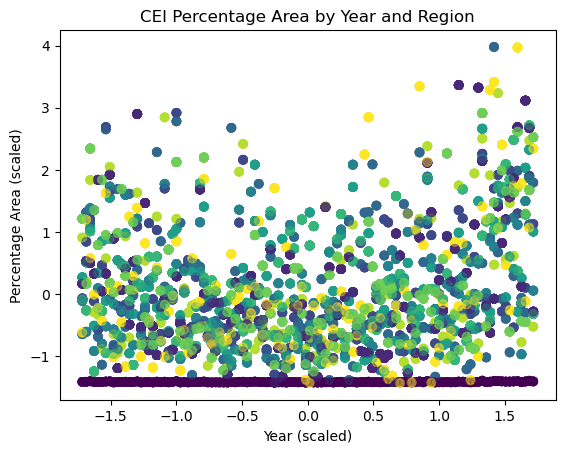

In [51]:
plt.scatter(Xpca2[:,1],Xpca2[:,2], alpha = 0.2, c = Xpca2[:,4])
plt.xlabel('Year (scaled)')
plt.ylabel('Percentage Area (scaled)')
plt.title('CEI Percentage Area by Year and Region')
plt.show()

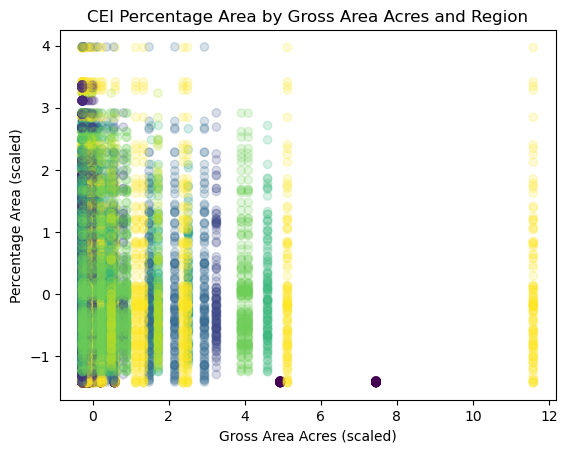

In [52]:
plt.scatter(Xpca2[:,0],Xpca2[:,2], alpha = 0.2, c = Xpca2[:,4])
plt.xlabel('Gross Area Acres (scaled)')
plt.ylabel('Percentage Area (scaled)')
plt.title('CEI Percentage Area by Gross Area Acres and Region')
plt.show()

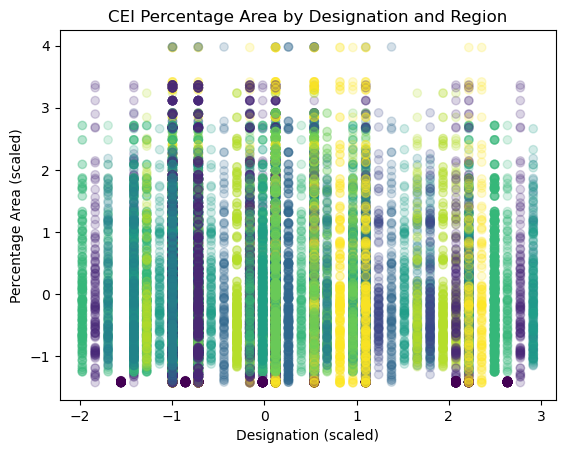

In [53]:
plt.scatter(Xpca2[:,3],Xpca2[:,2], alpha = 0.2, c = Xpca2[:,4])
plt.xlabel('Designation (scaled)')
plt.ylabel('Percentage Area (scaled)')
plt.title('CEI Percentage Area by Designation and Region')
plt.show()

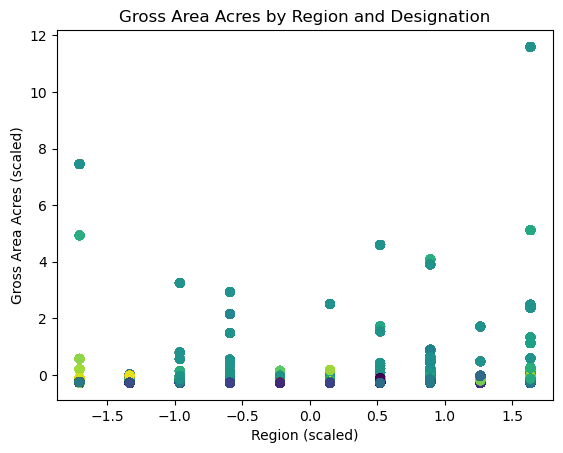

In [54]:
plt.scatter(Xpca2[:,4],Xpca2[:,0], alpha = 0.2, c = Xpca2[:,3])
plt.xlabel('Region (scaled)')
plt.ylabel('Gross Area Acres (scaled)')
plt.title('Gross Area Acres by Region and Designation')
plt.show()

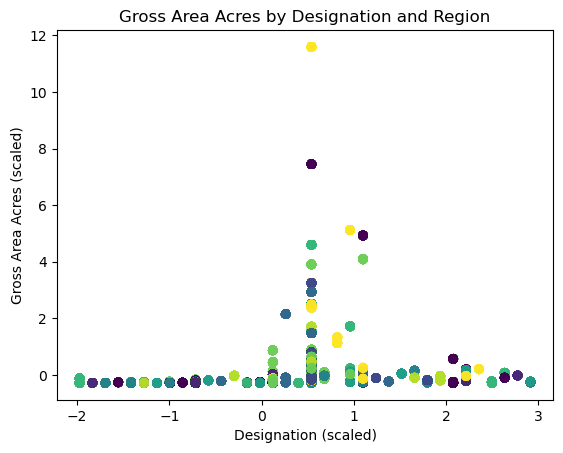

In [55]:
plt.scatter(Xpca2[:,3],Xpca2[:,0], alpha = 0.2, c = Xpca2[:,4])
plt.xlabel('Designation (scaled)')
plt.ylabel('Gross Area Acres (scaled)')
plt.title('Gross Area Acres by Designation and Region')
plt.show()

In [56]:
components = ['PC1', 'PC2', 'PC3','PC4','PC5']

c = len(components)

comp_add = [''] + components


In [57]:
pca = decomposition.PCA(n_components=5)
pca.fit(Xpca2)  

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [58]:
scores = pca.transform(Xpca2)
scores_df = pd.DataFrame(scores, columns=components)
scores_df

,PC1,PC2,PC3,PC4,PC5
0,-0.845554,-0.936929,-1.203076,0.429872,0.611772
1,-0.900034,-1.274390,-1.095403,0.380820,0.270180
2,-0.671390,0.164346,-1.428497,0.564732,1.568686
3,-0.931139,-1.460884,-1.001262,0.346778,0.037997
4,-0.813961,-0.721439,-1.160825,0.438972,0.690795
...,...,...,...,...,...
43495,1.336110,2.866433,0.198921,-0.117345,0.699586
43496,0.990445,0.702212,0.759909,-0.405993,-1.328796
43497,0.991012,0.710092,0.781884,-0.409750,-1.351508
43498,1.235262,2.246728,0.424496,-0.212997,0.037398


In [59]:
# The loadings value (eigendecomposition) tells about the descriptor and the scores values tells us about the data samples

loadings = pca.components_.T
loadings_df = pd.DataFrame(loadings, columns=components)
loadings_df

,PC1,PC2,PC3,PC4,PC5
0,0.592088,-0.207631,0.281519,0.719607,0.096092
1,0.070673,0.588104,0.655403,-0.083285,-0.461140
2,0.113949,0.714867,-0.177396,0.093761,0.660092
3,0.606814,-0.204243,0.223519,-0.682166,0.273405
4,0.513059,0.241399,-0.640128,-0.032981,-0.517344


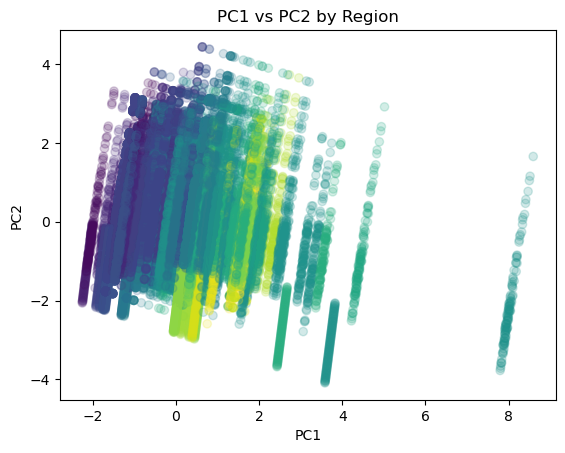

In [60]:
# Plot principal components
plt.scatter(scores_df['PC1'],scores_df['PC2'], alpha = 0.2, c = Xpca2[:,3])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2 by Region')
plt.show()

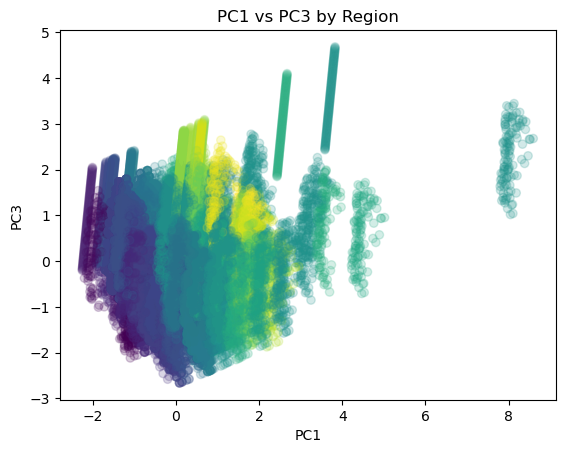

In [61]:
# Plot principal components
plt.scatter(scores_df['PC1'],scores_df['PC3'], alpha = 0.2, c = Xpca2[:,3])
plt.xlabel('PC1')
plt.ylabel('PC3')
plt.title('PC1 vs PC3 by Region')
plt.show()

In [62]:
# the explained variance will tell us what the contribution is to the explained variance of the entire model contributed 
# by each of the principle components. PC1, PC2, PC3 contribute to the overall variance of the data set. 

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.25530814, 0.24169674, 0.19071535, 0.16138216, 0.15089761])

In [63]:
# add origin value at 0,0, which means x and y we will have at zero because in the subsequent lines of code we will
explained_variance = np.insert(explained_variance, 0, 0)

In [64]:
# cumulative variance
cumulative_variance = np.cumsum(np.round(explained_variance, decimals=3))

In [65]:
pc_df = pd.DataFrame(comp_add, columns=['PC'])
explained_variance_df = pd.DataFrame(explained_variance, columns=['Explained Variance'])
cumulative_variance_df = pd.DataFrame(cumulative_variance, columns=['Cumulative Variance'])

In [66]:
df_explained_variance = pd.concat([pc_df, explained_variance_df, cumulative_variance_df], axis=1)
df_explained_variance

,PC,Explained Variance,Cumulative Variance
0,,0.000000,0.000
1,PC1,0.255308,0.255
2,PC2,0.241697,0.497
3,PC3,0.190715,0.688
4,PC4,0.161382,0.849
5,PC5,0.150898,1.000


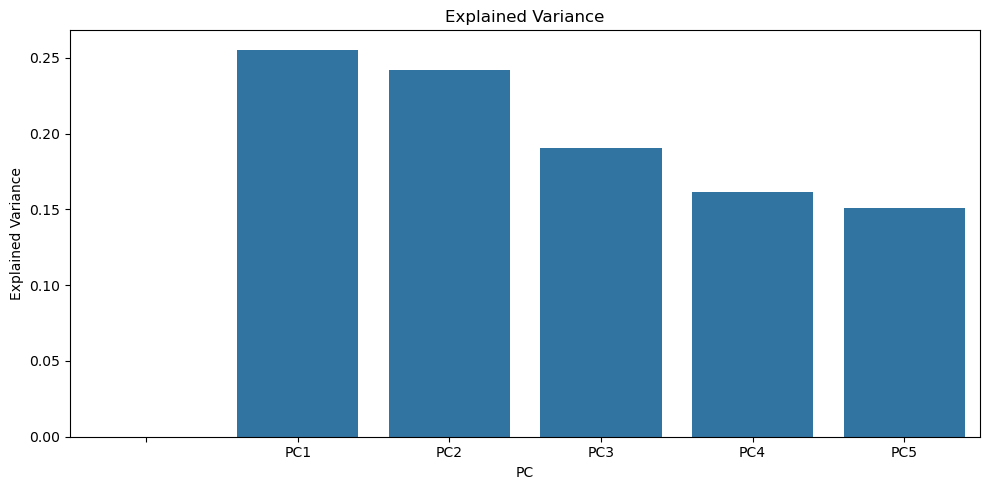

In [67]:
# Explained Variance Plot
plt.figure(figsize=(10, 5))#
sns.barplot(data=df_explained_variance, x='PC', y = 'Explained Variance')
plt.title(f'Explained Variance')
plt.xlabel('PC')
plt.ylabel('Explained Variance')
plt.subplots_adjust(left=0.3)
plt.tight_layout()

plt.show()

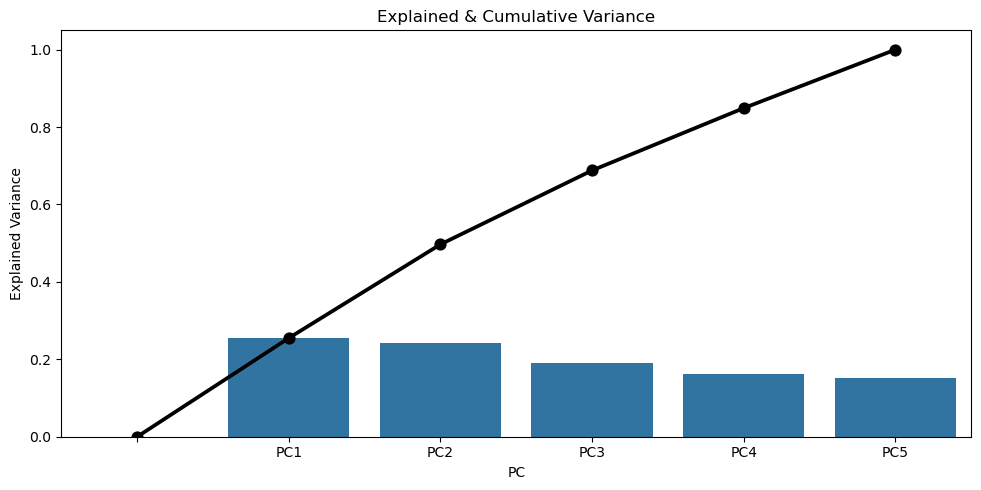

In [68]:
# Explained Variance & Cumulative Variance 
plt.figure(figsize=(10, 5))#
ax = sns.barplot(data=df_explained_variance, x='PC', y = 'Explained Variance')
plt.title(f'Explained & Cumulative Variance')
plt.xlabel('PC')
plt.ylabel('Explained Variance')
plt.subplots_adjust(left=0.3)
plt.tight_layout()

sns.pointplot(data=df_explained_variance, x='PC', y = 'Cumulative Variance', ax = ax, color = 'black')


plt.show()